In [32]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [33]:
# Load Dataset
# ==========================================
dataframe = pd.read_csv("./dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Drop unnecessary identifier column
dataframe = dataframe.drop(columns=["customerID"])

In [34]:
# Initial Data Inspection
# ==========================================
print(dataframe.head())
print(dataframe.describe())
print(dataframe.isnull().sum())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [35]:
# Target Distribution
# ==========================================
print(dataframe["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


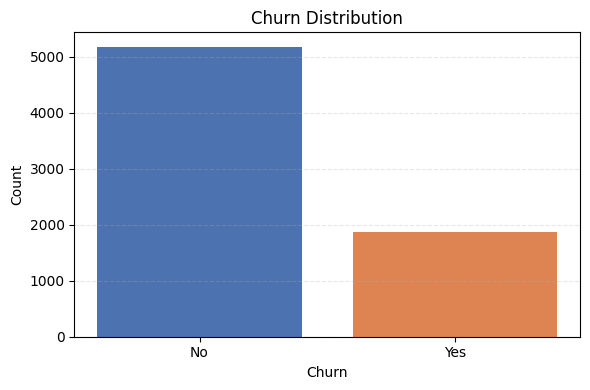

In [36]:
# Visualize Target Distribution
# ==========================================
plt.figure(figsize=(6, 4))
churn_counts = dataframe["Churn"].value_counts()

plt.bar(
    churn_counts.index.astype(str),
    churn_counts.values,
    color=["#4C72B0", "#DD8452"]
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Binary Feature Encoding
# ==========================================
binary_columns = ["Churn", "PhoneService", "Partner", "PaperlessBilling", "Dependents"]

for column in binary_columns:
    dataframe[column] = dataframe[column].replace({"Yes": 1, "No": 0})

dataframe["gender"] = dataframe["gender"].replace({"Female": 1, "Male": 0})

In [38]:
# Service Column Cleaning
# ==========================================
service_columns = [
    "OnlineSecurity",
    "MultipleLines",
    "DeviceProtection",
    "OnlineBackup",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

for column in service_columns:
    dataframe[column] = dataframe[column].replace(
        {
            "No phone service": "No",
            "No internet service": "No",
        }
    )
    dataframe[column] = dataframe[column].replace({"Yes": 1, "No": 0})

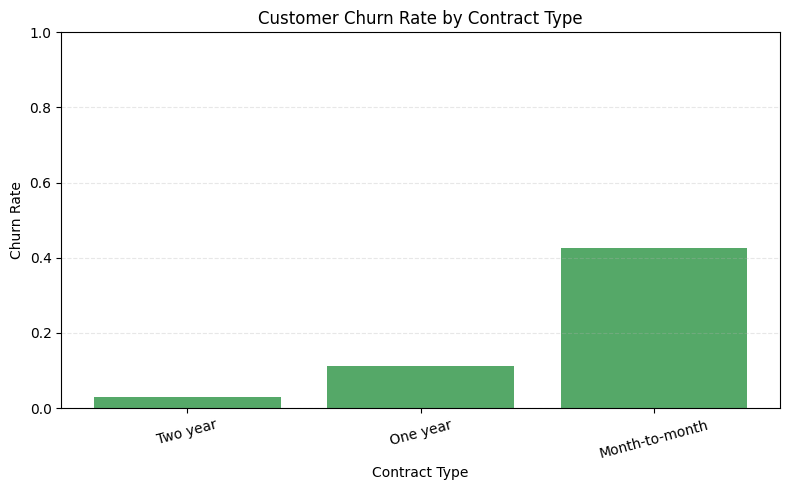

In [39]:
# Visualize Churn Rate By Contract Type
# ==========================================
# This visualization helps understand how contract type influences churn rate.
# It's plotted before One-Hot Encoding to use the original 'Contract' column.
contract_churn_rate = dataframe.groupby("Contract")["Churn"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(
    contract_churn_rate.index,
    contract_churn_rate.values,
    color="#55A868" # A green shade for a positive correlation indicator
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.ylim(0, 1) # Churn rate is between 0 and 1
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=15) # Rotate labels for better readability if they overlap
plt.tight_layout()
plt.show()

In [40]:
# One-Hot Encoding
# ==========================================
dataframe = pd.get_dummies(
    dataframe,
    columns=["Contract", "PaymentMethod", "InternetService"],
)

bool_columns = dataframe.select_dtypes(include="bool").columns
dataframe[bool_columns] = dataframe[bool_columns].astype(int)

In [41]:
# Numeric Cleaning
# ==========================================
dataframe["TotalCharges"] = pd.to_numeric(dataframe["TotalCharges"], errors="coerce")
dataframe["TotalCharges"] = dataframe["TotalCharges"].fillna(dataframe["TotalCharges"].median())

In [42]:
# Feature and Target Separation
# ==========================================
features = dataframe.drop(columns=["Churn"])
target = dataframe["Churn"]

In [43]:
# Non-Numeric Column Check
# ==========================================
for column in features.columns:
    try:
        pd.to_numeric(features[column])
    except Exception:
        print(f"Non-numeric value found in column '{column}': {features[column].iloc[0]}")
        break
else:
    print("No non-numeric columns found in features.")


No non-numeric columns found in features.


In [44]:
# Train / Validation Split
# ==========================================
X_train, X_valid, y_train, y_valid = train_test_split(
    features,
    target,
    test_size=0.15,
    random_state=2022,
)

In [45]:


# Model Training
# ==========================================
models = [
    LogisticRegression(max_iter=10000),
    KNeighborsClassifier(),
    DecisionTreeClassifier(),
]

for model in models:
    model.fit(X_train, y_train)

In [46]:
# Model Evaluation
# ==========================================
for model in models:
    train_auc = metrics.roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    valid_auc = metrics.roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])

    print(f"{model.__class__.__name__}")
    print(f"Training ROC AUC:   {train_auc:.4f}")
    print(f"Validation ROC AUC: {valid_auc:.4f}")
    print("-" * 35)

LogisticRegression
Training ROC AUC:   0.8449
Validation ROC AUC: 0.8635
-----------------------------------
KNeighborsClassifier
Training ROC AUC:   0.8894
Validation ROC AUC: 0.7624
-----------------------------------
DecisionTreeClassifier
Training ROC AUC:   1.0000
Validation ROC AUC: 0.6464
-----------------------------------
